<a href="https://colab.research.google.com/github/melnotte/store-analysis/blob/main/Store_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Summary

This project presents a data-driven evaluation of four retail branches to determine the optimal candidate for divestment. By conducting a comparative analysis of key performance indicators (KPIs) including Total Revenue, Customer Satisfaction (Ratings), Shipping Costs, and Sales Volume per Category. The study identifies which store is currently a "weak link" in the portfolio. The objective is to provide a clear verdict based on financial viability and market performance, ensuring that corporate resources are allocated to the most efficient locations.

### Import data






In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [ ]:
stores = [tienda, tienda2, tienda3, tienda4]

In [ ]:
for i, df in enumerate(stores, start=1):
  print(f'\n\nSTORE {i}\n-------------------------------------------------------')
  df.info()



STORE 1
-------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


STORE 2
-----------

In [ ]:
for i, store in enumerate(stores, start=1):
  print(f'\n\nSTORE {i}\n-------------------------------------------------------')
  print({store.duplicated().sum()})



STORE 1
-------------------------------------------------------
{np.int64(0)}


STORE 2
-------------------------------------------------------
{np.int64(0)}


STORE 3
-------------------------------------------------------
{np.int64(0)}


STORE 4
-------------------------------------------------------
{np.int64(0)}


In [ ]:
for i, store in enumerate(stores, start=1):
  print(f'\n\nStore {i}\n-------------------------------------------------------')
  print(store.describe())



Store 1
-------------------------------------------------------
             Precio  Costo de envío  Calificación  Cantidad de cuotas  \
count  2.359000e+03     2359.000000   2359.000000         2359.000000   
mean   4.878679e+05    26018.609580      3.976685            2.943196   
std    6.146868e+05    32860.001783      1.415370            2.819897   
min    7.600000e+03        0.000000      1.000000            1.000000   
25%    5.575000e+04     3100.000000      3.000000            1.000000   
50%    2.353000e+05    12400.000000      5.000000            1.000000   
75%    6.781000e+05    36000.000000      5.000000            4.000000   
max    2.977000e+06   160800.000000      5.000000           24.000000   

               lat          lon  
count  2359.000000  2359.000000  
mean      5.365283   -74.789417  
std       2.287445     1.217827  
min      -4.215280   -77.281110  
25%       4.609710   -75.563590  
50%       4.609710   -74.199040  
75%       6.251840   -74.081750  
max 

#1. Revenue Analysis



In [ ]:
revenue_per_store = {f'Store_{i}': df['Precio'].sum() for i, df in enumerate(stores, 1)}
revenue_per_store

{'Store_1': np.float64(1150880400.0),
 'Store_2': np.float64(1116343500.0),
 'Store_3': np.float64(1098019600.0),
 'Store_4': np.float64(1038375700.0)}

In [ ]:
for store, total in revenue_per_store.items():
    print(f"{store}: ${total:,.2f}")

Store_1: $1,150,880,400.00
Store_2: $1,116,343,500.00
Store_3: $1,098,019,600.00
Store_4: $1,038,375,700.00


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

(0.0, 1726320600.0)

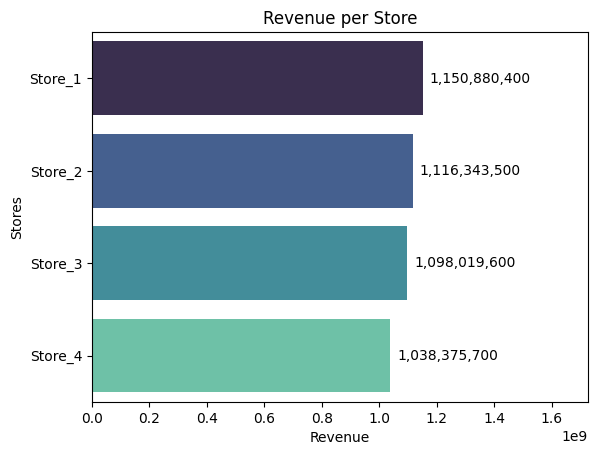

In [ ]:
ax = sns.barplot(x=list(revenue_per_store.values()), y=list(revenue_per_store.keys()), hue=list(revenue_per_store.keys()), palette="mako")
ax.set(xlabel='Revenue', ylabel='Stores', title='Revenue per Store')

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=5)

ax.set_xlim(right=max(revenue_per_store.values()) * 1.5)


# 2. Sales by category

In [ ]:
sales_by_category = {f'Store_{i}': df.groupby('Categoría del Producto')['Precio'].sum() for i, df in enumerate(stores, 1)}
sales_by_category

{'Store_1': Categoría del Producto
 Artículos para el hogar     12698400.0
 Deportes y diversión        39290000.0
 Electrodomésticos          363685200.0
 Electrónicos               429493500.0
 Instrumentos musicales      91299000.0
 Juguetes                    17995700.0
 Libros                       8784900.0
 Muebles                    187633700.0
 Name: Precio, dtype: float64,
 'Store_2': Categoría del Producto
 Artículos para el hogar     14746900.0
 Deportes y diversión        34744500.0
 Electrodomésticos          348567800.0
 Electrónicos               410831100.0
 Instrumentos musicales     104990300.0
 Juguetes                    15945400.0
 Libros                      10091200.0
 Muebles                    176426300.0
 Name: Precio, dtype: float64,
 'Store_3': Categoría del Producto
 Artículos para el hogar     15060000.0
 Deportes y diversión        35593100.0
 Electrodomésticos          329237900.0
 Electrónicos               410775800.0
 Instrumentos musicales      7738

In [ ]:
df = []

for store, series in sales_by_category.items():
  temp_df = series.reset_index()
  temp_df.columns = ['Category', 'Sales']
  temp_df['Store'] = store
  df.append(temp_df)

df = pd.concat(df)
df


,Category,Sales,Store
0,Artículos para el hogar,12698400.0,Store_1
1,Deportes y diversión,39290000.0,Store_1
2,Electrodomésticos,363685200.0,Store_1
3,Electrónicos,429493500.0,Store_1
4,Instrumentos musicales,91299000.0,Store_1
5,Juguetes,17995700.0,Store_1
6,Libros,8784900.0,Store_1
7,Muebles,187633700.0,Store_1
0,Artículos para el hogar,14746900.0,Store_2
1,Deportes y diversión,34744500.0,Store_2


In [ ]:
fig = px.pie(
    df,
    values='Sales',
    names='Category',
    facet_col='Store',
    facet_col_wrap=2,
    title='Sales by Category',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(
    textposition='inside',
    insidetextorientation='radial',
    hovertemplate="<b>%{label}</b><br>Sales: $%{value:,.0f}<br>Percentage: %{percent}<extra></extra>"
)

fig.update_layout(
    uniformtext_minsize=12,
    uniformtext_mode='hide',
)

fig.show()

# 3. Average store rating

In [ ]:
average_store_rating = {f'Store_{i}': df['Calificación'].mean() for i, df in enumerate(stores, 1)}
average_store_rating

{'Store_1': np.float64(3.976685036032217),
 'Store_2': np.float64(4.037303942348453),
 'Store_3': np.float64(4.048325561678677),
 'Store_4': np.float64(3.9957591178965224)}

In [ ]:
df_stores = pd.concat(stores, keys=['Store_1', 'Store_2', 'Store_3', 'Store_4'])
df_stores = df_stores.reset_index().rename(columns={'level_0': 'Store'})
df_stores

,Store,level_1,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Store_1,0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Store_1,1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Store_1,2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Store_1,3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Store_1,4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,Store_4,2353,Mesa de comedor,Muebles,227700.0,12600.0,12/02/2020,Camila Rivera,Medellín,5,Tarjeta de crédito,1,6.25184,-75.56359
9431,Store_4,2354,Silla de oficina,Muebles,342000.0,18600.0,17/05/2022,Felipe Santos,Bucaramanga,5,Tarjeta de crédito,3,7.12539,-73.11980
9432,Store_4,2355,Vaso térmico,Deportes y diversión,36700.0,2400.0,03/05/2022,Camila Rivera,Bogotá,5,Tarjeta de crédito,1,4.60971,-74.08175
9433,Store_4,2356,Set de ollas,Artículos para el hogar,151800.0,8300.0,15/06/2020,Blanca Ramirez,Cali,5,Tarjeta de crédito,1,3.43722,-76.52250


/tmp/ipython-input-603789363.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




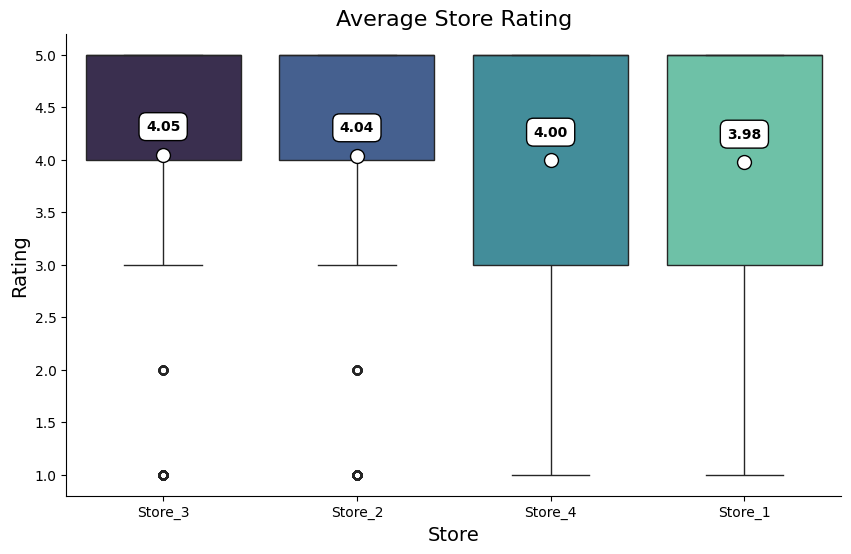

In [ ]:
store_means = df.groupby('Store')['Calificación'].mean().sort_values(ascending=False)
sort_order = store_means.index

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df,
    x='Store',
    y='Calificación',
    order=sort_order,
    palette='mako',
    showmeans=True,
    meanprops={'marker': 'o', 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'markersize':'10'}
)

for i, store in enumerate(sort_order):
  mean_value = store_means[store]
  ax.text(
      i,
      mean_value + 0.2,
      f'{mean_value:.2f}',
      ha='center',
      va='bottom',
      fontweight='bold',
      color='black',
      bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
  )


sns.despine()
plt.title('Average Store Rating', fontsize=16)
plt.xlabel('Store', fontsize=14)
plt.ylabel('Rating', fontsize=14)
plt.show()


# 4. Top and Bottom Products



In [ ]:
top_and_bottom_prod = {f'Store_{i}': df.groupby('Producto')['Cantidad de cuotas'].sum() for i, df in enumerate(stores, 1)}
top_and_bottom_prod

{'Store_1': Producto
 Ajedrez de madera              129
 Armario                        145
 Asistente virtual              129
 Auriculares                    152
 Auriculares con micrófono      103
 Balón de baloncesto            167
 Balón de voleibol              136
 Batería                        143
 Bicicleta                      178
 Bloques de construcción        161
 Cama box                       150
 Cama king                      126
 Carrito de control remoto      145
 Celular ABXY                    78
 Ciencia de datos con Python    141
 Cubertería                     148
 Cubo mágico 8x8                101
 Cuerda para saltar             100
 Dashboards con Power BI        129
 Dinosaurio Rex                  94
 Estufa                         120
 Guitarra acústica              140
 Guitarra eléctrica             167
 Impresora                      182
 Iniciando en programación      113
 Iphone 15                      134
 Juego de mesa                  121
 Kit de

In [ ]:
from re import template
for store, series in top_and_bottom_prod.items():
  df = series.reset_index()
  df.columns = ['Product', 'Quantity']
  df = df.sort_values(by='Quantity',ascending=False)

  '''top_5 = df.head(5)
  bottom_5 = df.tail(5)
  df = pd.concat([top_5, bottom_5]).drop_duplicates()'''

  fig = px.bar(
      df,
      x='Product',
      y='Quantity',
      color='Quantity',
      title=f'Top and Bottom Products for {store}',
      color_continuous_scale='Ice',
      text_auto=True,
      template='plotly_white'
  )

  fig.update_layout(
      xaxis_title='Product',
      yaxis_title='Quantity',
      xaxis={'categoryorder': 'total descending'},
      template='plotly_white',
      height=600
  )

  fig.show()

# 5. Average Shipping per Store

In [ ]:
average_shipping_store = {f'Store_{i}': df['Costo de envío'].mean() for i, df in enumerate(stores, 1)}
average_shipping_store

{'Store_1': np.float64(26018.60958033065),
 'Store_2': np.float64(25216.235693090293),
 'Store_3': np.float64(24805.680373039424),
 'Store_4': np.float64(23459.457167090754)}

/tmp/ipython-input-1490288623.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Figure size 640x480 with 0 Axes>

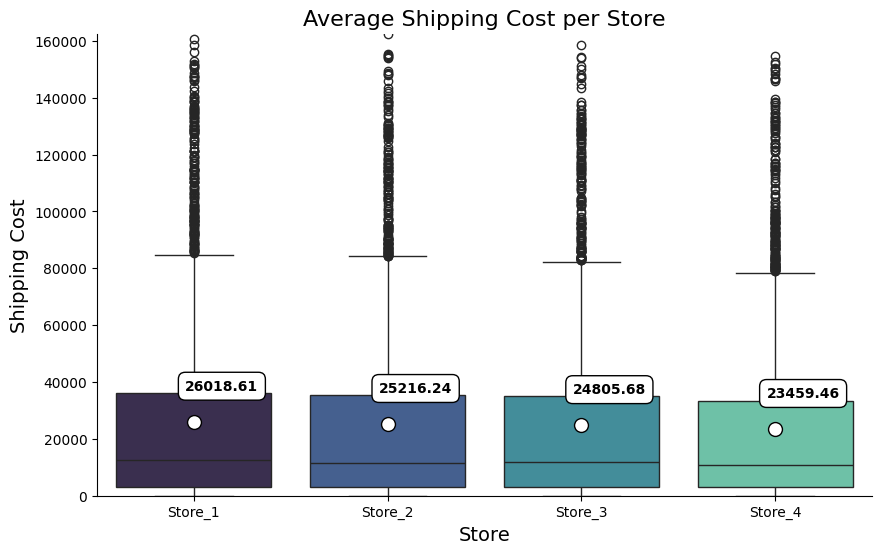

In [ ]:
from matplotlib import transforms
from matplotlib.transforms import offset_copy
otxt = offset_copy(ax.transData, fig=plt.gcf(), y=15, units='points')

shipping_means = df.groupby('Store')['Costo de envío'].mean().sort_values(ascending=False)
sort_order = shipping_means.index

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df_stores,
    x='Store',
    y='Costo de envío',
    order=sort_order,
    palette='mako',
    showmeans=True,
    meanprops={'marker': 'o', 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'markersize':'10'}
)

y_max = df['Costo de envío'].max()
plt.ylim(0, y_max + 40)

for i, store in enumerate(sort_order):
  mean_value = shipping_means[store]
  ax.text(
      i,
      mean_value,
      f'{mean_value:.2f}',
      transform=otxt,
      ha='center',
      va='bottom',
      fontweight='bold',
      color='black',
      bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
  )


sns.despine()
plt.title('Average Shipping Cost per Store', fontsize=16)
plt.xlabel('Store', fontsize=14)
plt.ylabel('Shipping Cost', fontsize=14)
sns.despine()
plt.show()


# FINAL REPORT

|Analysis|Store 1|Store 2|Store 3|Store 4|
|-------|-------|-------|-------|-------|
|Revenue|1150880400.0|1116343500.0|1098019600.0|1038375700.0|
|Average store rating|3.98/5|4.04/5|4.05/5|4.0/5|
|Average Shipping Cost|26018.61|25216.24|24805.68|23459.46|
|Max Sales Volume|214|223|191|196|
|Min Sales Volume|78|89|94|88|

Based on the comprehensive multi-variable analysis of the four stores, the data clearly indicates that Store 4 should be sold. The verdict is supported by the fact that Store 4 underperformed in 4 out of the 5 primary metrics evaluated:

* **Revenue Performance:** Store 4 generated the lowest total revenue (1,038,375,700), trailing Store 1 (the leader) by over $112 million.

* **Operational Instability:** It recorded the lowest Minimum Sales Volume, indicating high volatility and inconsistent daily performance.

* **Customer Perception:** it holds the second lowest average rating (3.99/5), suggesting a potential local market dissatisfaction or lower service quality compared to Stores 2 and 3 (which boast ratings of 4.04 and 4.05).

* **Shipping & Logistics:** it has the lowest shipping costs, which in this context is a symptom of its significantly lower sales activity rather than high logistics efficiency.

* **Market Share:** while other stores maximize Electronics and Appliances items, Store 4 shows the lowest penetration in these essential segments.

Selling Store 4 is the most strategic move to mitigate financial risk and optimize the overall profitability of the retail chain.